# Milestone 2 — photo check on the masked top 12, and Hesaraghatta against its map

`m2_masked.ipynb` re-ranked the hexes with mapped water masked out. The top of the new list still
leans on lake shorelines and wetlands, and numbers alone can't say which of those are real change.
This notebook looks.

1. **Where water really was, outside the mask.** For each of the top 12, the share of its *remaining
   land* that still reads as open water in each year. Anything well above zero means the real
   water edge sits outside OSM's outline, and the "land" being measured is partly lake.
2. **The photos.** Eight years of each hex, with the hex in yellow, the masked OSM water in red and
   the wetlands that were kept in magenta.
3. **Hesaraghatta Lake against its OSM outline.** One lake, all eight years: where OSM says the water
   is, and where the satellite actually saw it.

**Needs Earth Engine.** Run with `EE_PROJECT` set.

In [1]:
import io
import os
import socket
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box as shapely_box

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
METRIC = "EPSG:32643"
RGB_MAX = 3000
NDVI_RANGE = (-0.2, 0.8)
NDVI_PALETTE = ["#8c510a", "#d8b365", "#f6e8c3", "#c7eae5", "#5ab4ac", "#01665e"]
HEX_EDGE, MASK_EDGE, WETLAND_EDGE, WATER_FILL = "#ffe600", "#ff2d2d", "#ff4dff", "#1f78ff"
TOP = 12

table = pd.read_csv("results/m2_hex_table_masked.csv")
old_px = pd.read_csv("results/m2_hex_table.csv").groupby("h3").n_pixels.median()
green = table.pivot(index="h3", columns="year", values="green")
YEARS = list(green.columns)
norm = green.sub(green.mean(axis=0), axis=1)
change = norm[YEARS[-1]] - norm[YEARS[0]]
top = change.abs().nlargest(TOP).index
land = table.groupby("h3").n_pixels.median() / old_px

osm = gpd.read_file("data/osm_water.geojson")
masked = osm[osm["class"] != "wetland"]
wetland = osm[osm["class"] == "wetland"]

socket.setdefaulttimeout(120)
ee.Initialize(project=os.environ["EE_PROJECT"])
ee.data.setDeadline(120_000)


def retry(fetch, tries=4):
    for attempt in range(tries):
        try:
            return fetch()
        except Exception as exc:
            if attempt == tries - 1:
                raise
            print(f"  retrying after {type(exc).__name__}")


def hex_geom(hx):
    return ee.Geometry.Polygon([[[lng, lat] for lat, lng in h3.cell_to_boundary(hx)]])


def composite(year, region):
    return (ee.ImageCollection(COLLECTION).filterBounds(region)
            .filterDate(f"{year}-02-01", f"{year}-03-31").median())


def is_water(image):
    return image.normalizedDifference(["B3", "B11"]).gt(0)


def to_fc(frame):
    return ee.FeatureCollection([ee.Feature(ee.Geometry(g.__geo_interface__)) for g in frame.geometry])


def near(frame, bounds):
    return frame[frame.intersects(shapely_box(*bounds))]


def land_mask(bounds):
    lakes = near(masked, bounds)
    return ee.Image.constant(1).paint(to_fc(lakes), 0) if len(lakes) else ee.Image.constant(1)


def outline(frame, colour, width=2):
    if frame.empty:
        return None
    return ee.Image().byte().paint(to_fc(frame), 1, width).selfMask().visualize(palette=[colour])


def thumb(image, region, fmt, px=260):
    def fetch():
        url = image.getThumbURL({"region": region, "dimensions": px, "format": fmt})
        return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format=fmt)
    return retry(fetch)


print(f"top {TOP} by end-minus-start on the masked table; Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


top 12 by end-minus-start on the masked table; Earth Engine ready


---
## 1 — Water the mask missed

For each hex and year: of the pixels the mask *kept* as land, the share that read as open water
(wetness index above zero). This is the shoreline problem measured directly. A hex that shows 0-1%
every year is being measured on dry land. One that jumps to 20% in some years has lake inside its
"land" in those years, and that alone will move its greenness.

In [2]:
leak = {}
for hx in top:
    lat, lng = h3.cell_to_latlng(hx)
    bounds = (lng - 0.01, lat - 0.01, lng + 0.01, lat + 0.01)
    mask = land_mask(bounds)
    geom = hex_geom(hx)
    shares = ee.List([is_water(composite(y, geom)).updateMask(mask)
                      .reduceRegion(ee.Reducer.mean(), geom, 10).values().get(0) for y in YEARS])
    leak[hx] = retry(shares.getInfo)

leak = pd.DataFrame(leak, index=YEARS).T
view = leak.map(lambda v: "" if v is None else f"{v:.0%}")
view.insert(0, "change", change[top].round(3))
view.insert(1, "land", land[top].map("{:.0%}".format))
view.insert(0, "rank", range(1, TOP + 1))
print("share of each hex's remaining land that read as open water, by year")
print(view.to_string())
print(f"\nhexes whose land read >5% water in any year: {(leak.max(axis=1) > 0.05).sum()} of {TOP}")

share of each hex's remaining land that read as open water, by year
                 rank  change  land 2019 2020 2021 2022  2023 2024 2025 2026
8861893493fffff     1   0.312   32%  42%  33%  33%  30%    9%  11%  18%  12%
88618921a3fffff     2  -0.226  100%   0%   0%   0%   0%    0%   0%   0%   0%
8861892c69fffff     3  -0.221   56%   0%   0%   0%   0%    0%   0%   0%   0%
88601694a5fffff     4   0.198   32%   0%   0%   0%   0%    0%   0%   0%   0%
88618921b5fffff     5  -0.198  100%   0%   0%   0%   0%    1%   0%   0%   0%
8860169685fffff     6  -0.195   92%   0%   0%   0%   0%    0%   0%   0%   0%
8860169481fffff     7   0.181    0%   0%   0%   0%   0%  100%  96%   0%   0%
8861892c61fffff     8  -0.180   90%   0%   0%   0%   0%    0%   0%   1%   1%
886016968bfffff     9  -0.180   86%   0%   0%   0%   0%    0%   0%   0%   0%
8860169681fffff    10  -0.173  100%   0%   0%   0%   0%    0%   0%   0%   0%
88618921a1fffff    11  -0.170   99%   0%   0%   0%   0%    0%   0%   0%   0%
88618925

---
## 2 — The photos

Top row true colour, bottom row greenness, the same fixed scale as the deep dive. The number under
each year is the hex's normalised greenness from the masked table, the value the ranking uses.
Yellow is the hex, red is masked OSM water, magenta is kept wetland.

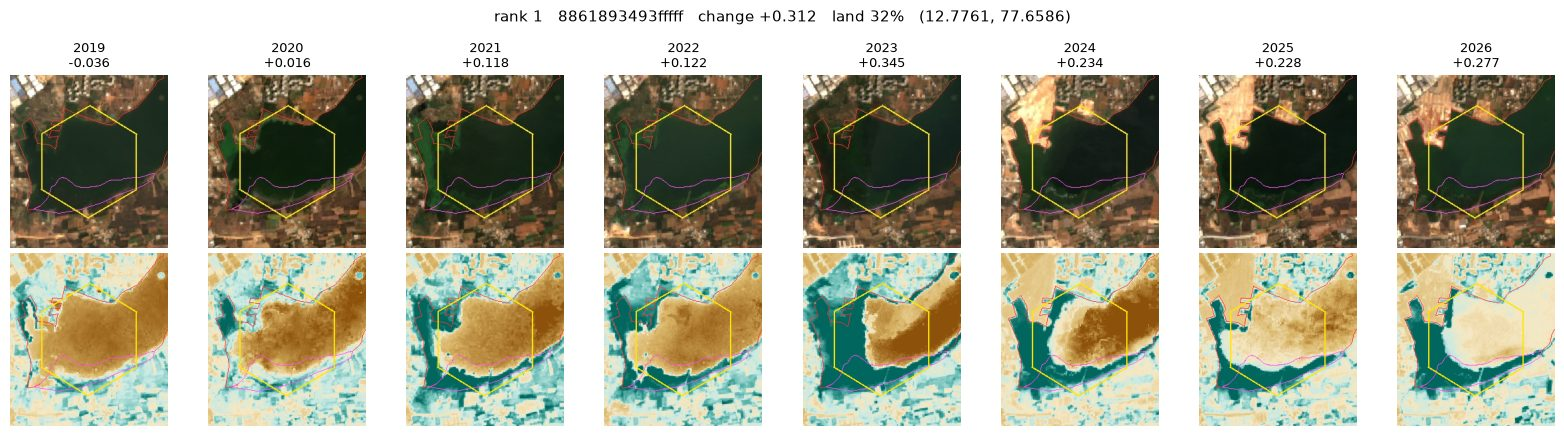

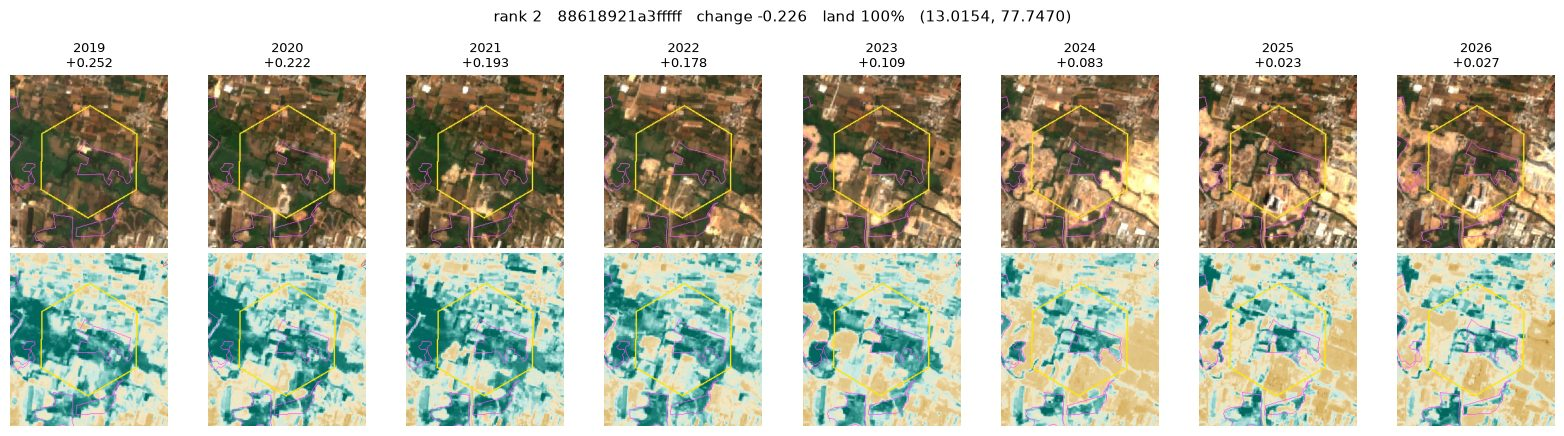

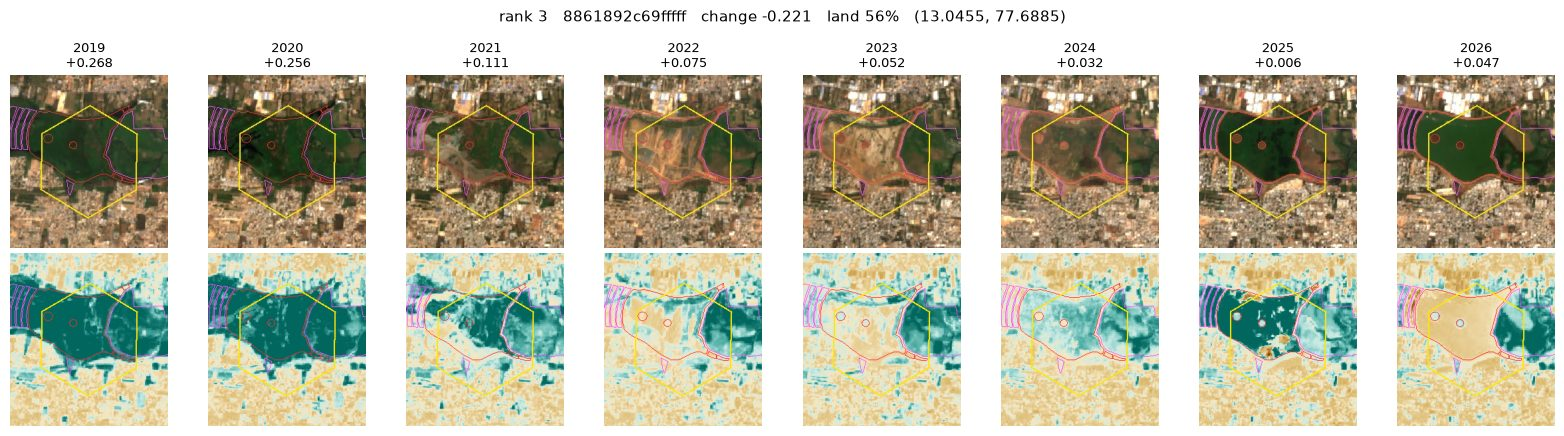

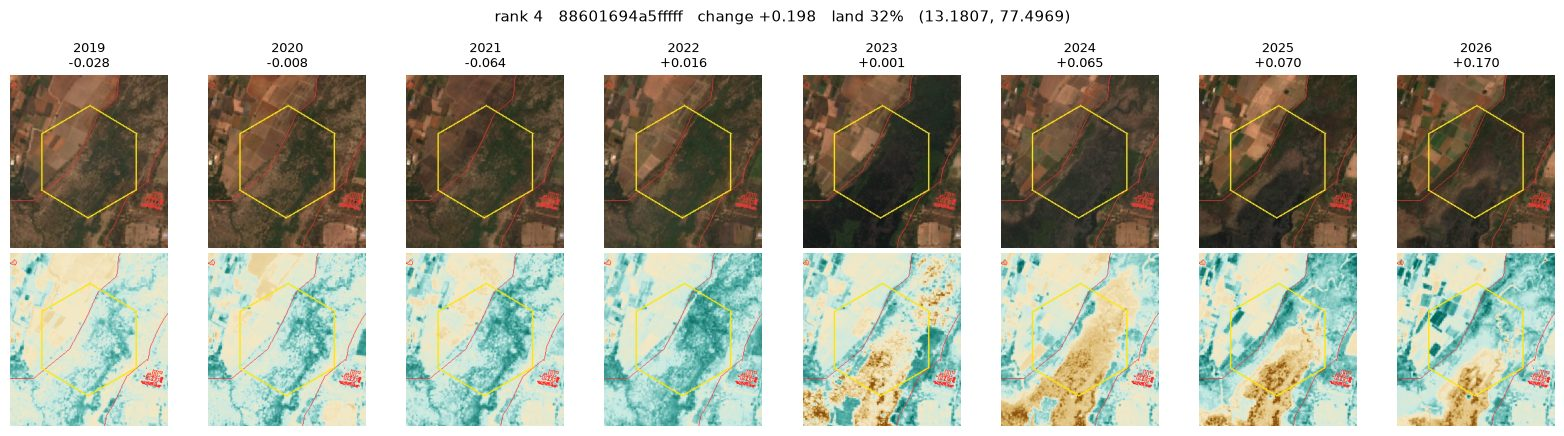

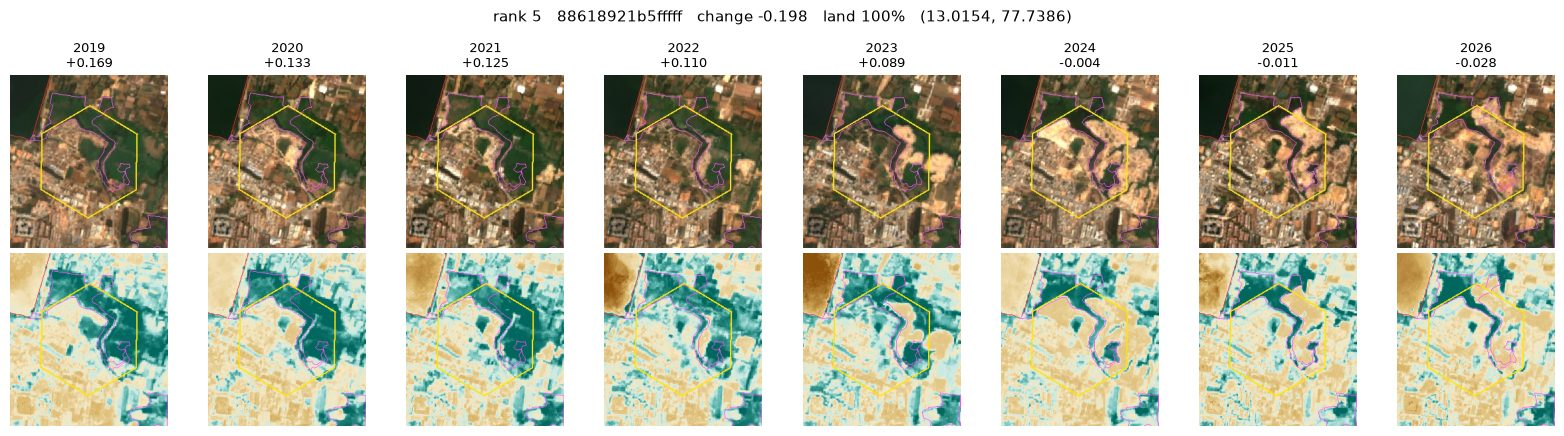

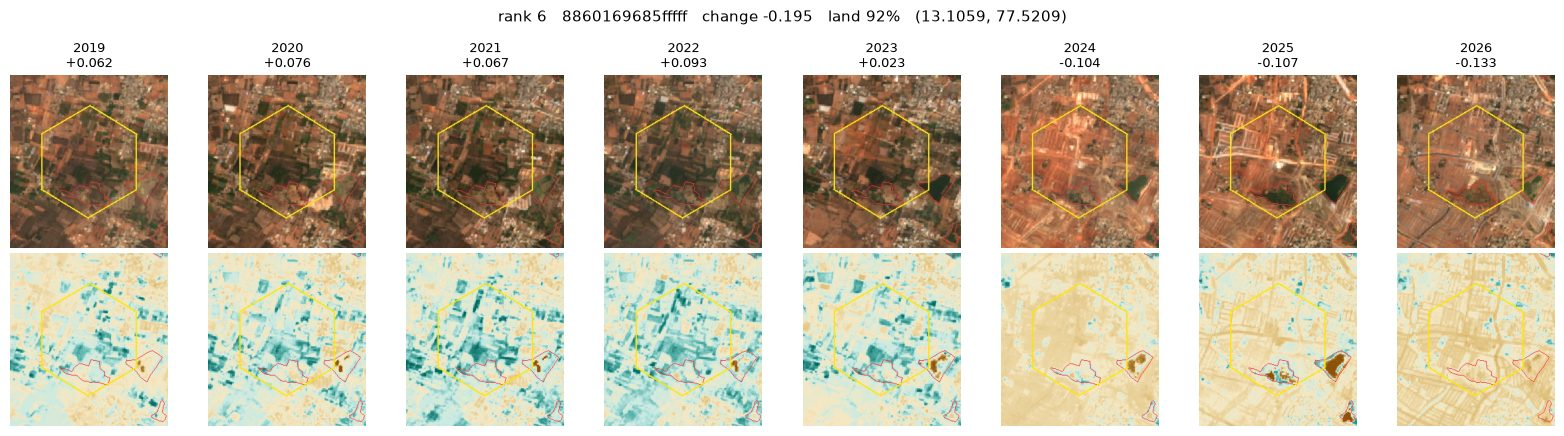

  retrying after HTTPError


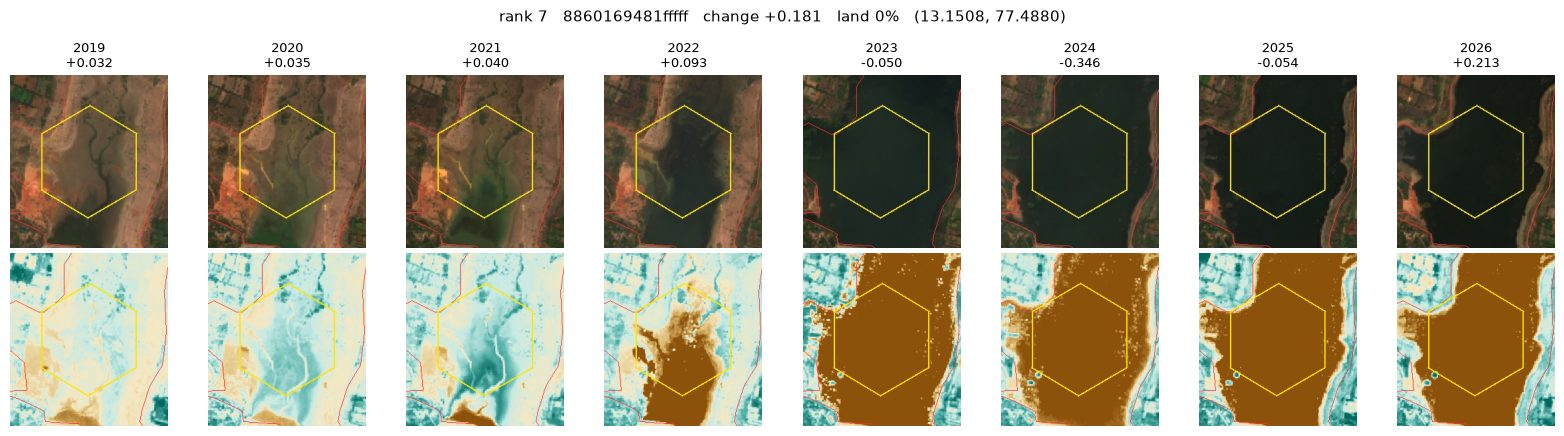

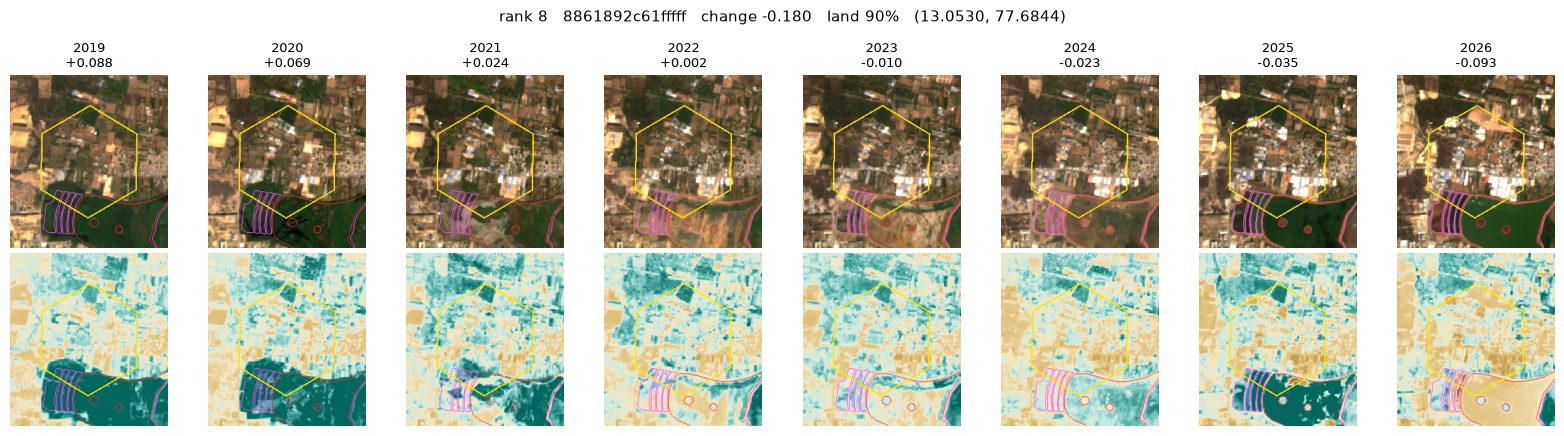

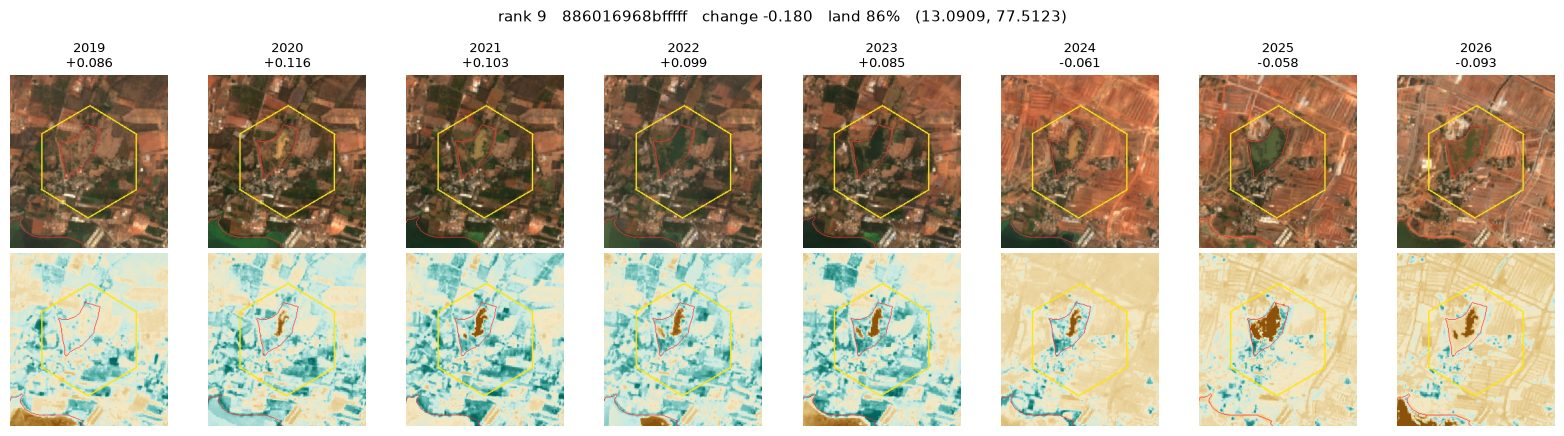

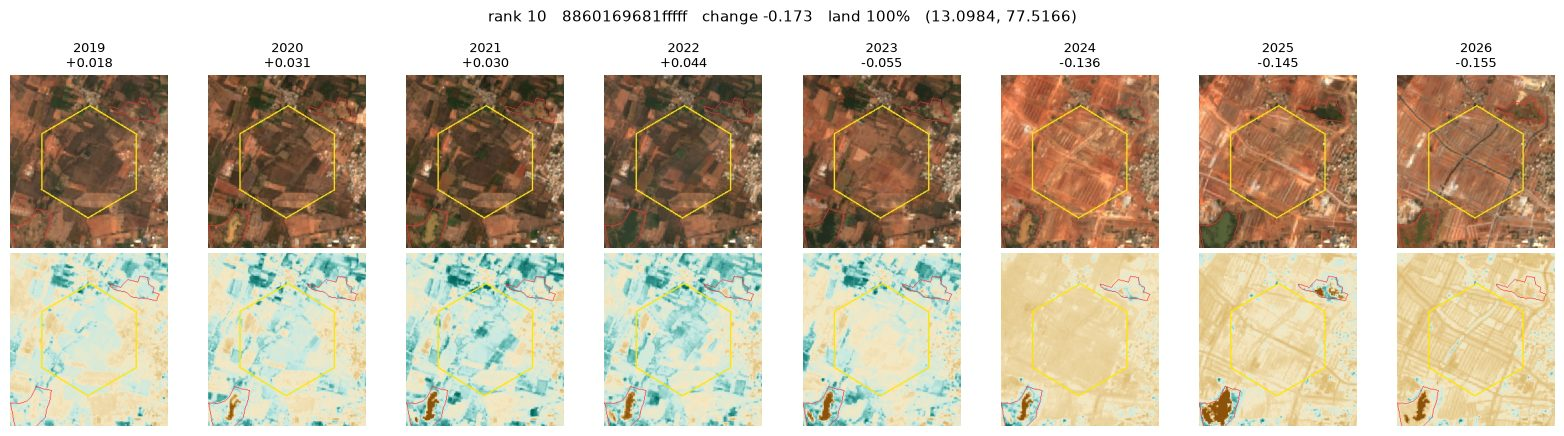

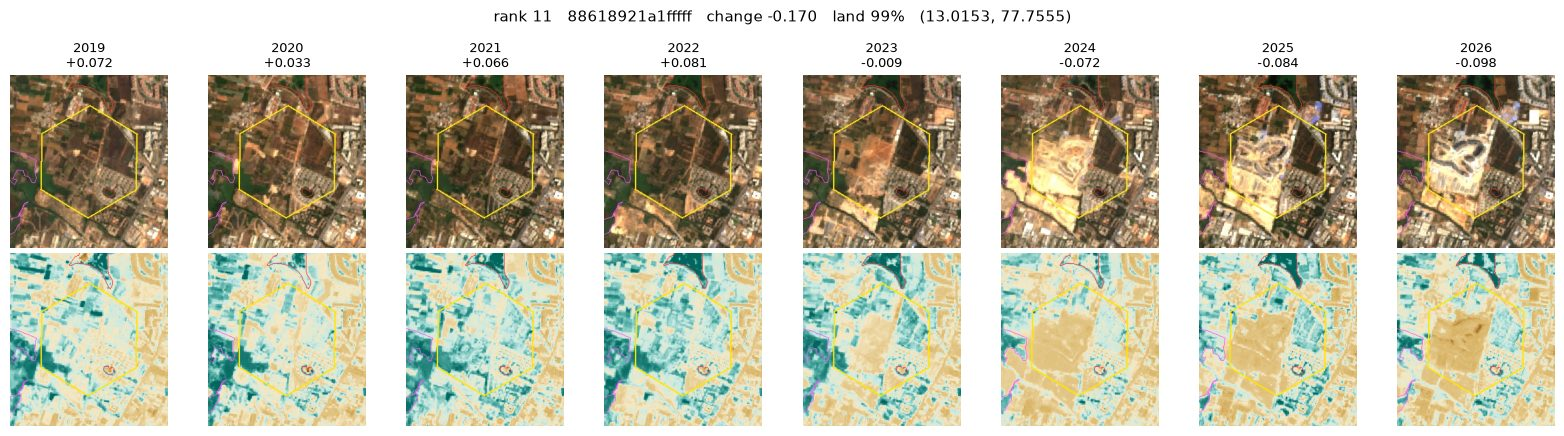

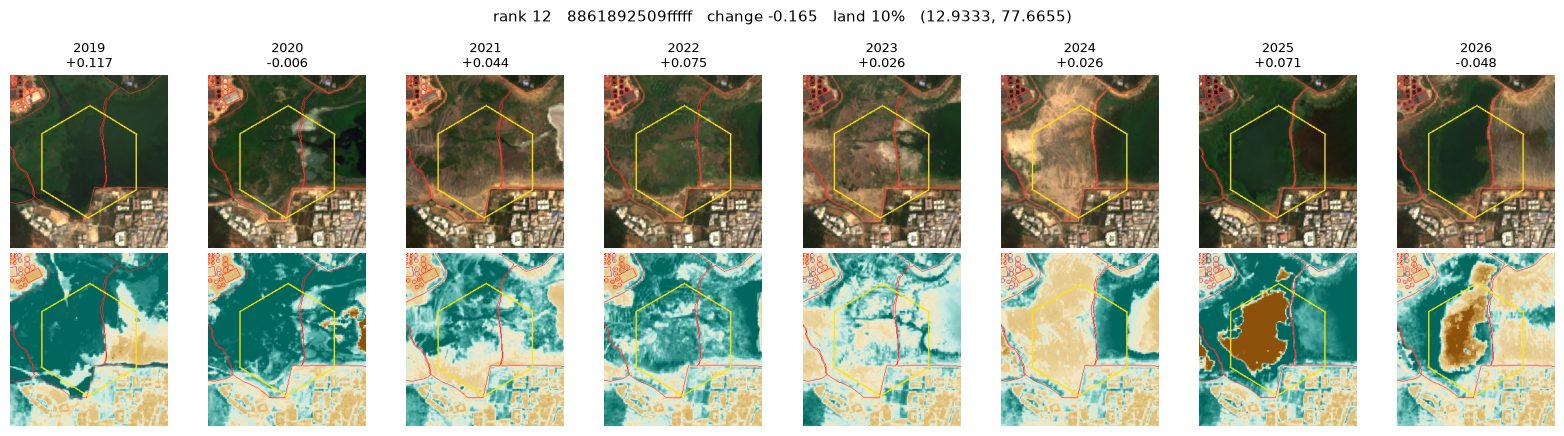

In [3]:
for rank, hx in enumerate(top, 1):
    geom = hex_geom(hx)
    lat, lng = h3.cell_to_latlng(hx)
    region = geom.buffer(300).bounds()
    bounds = (lng - 0.012, lat - 0.012, lng + 0.012, lat + 0.012)
    edges = [e for e in (outline(near(masked, bounds), MASK_EDGE, 1),
                         outline(near(wetland, bounds), WETLAND_EDGE, 1),
                         ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(geom)]), 1, 2)
                         .selfMask().visualize(palette=[HEX_EDGE])) if e is not None]
    fig, axes = plt.subplots(2, len(YEARS), figsize=(16, 4.4))
    for i, year in enumerate(YEARS):
        comp = composite(year, region)
        rgb = comp.visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX)
        ndvi = comp.normalizedDifference(["B8", "B4"]).visualize(
            min=NDVI_RANGE[0], max=NDVI_RANGE[1], palette=NDVI_PALETTE)
        for e in edges:
            rgb, ndvi = rgb.blend(e), ndvi.blend(e)
        axes[0][i].imshow(thumb(rgb, region, "jpg"))
        axes[1][i].imshow(thumb(ndvi, region, "png"))
        axes[0][i].set_title(f"{year}\n{norm.loc[hx, year]:+.3f}", fontsize=9)
        for ax in axes[:, i]:
            ax.set_axis_off()
    fig.suptitle(f"rank {rank}   {hx}   change {change[hx]:+.3f}   land {land[hx]:.0%}   "
                 f"({lat:.4f}, {lng:.4f})", fontsize=11)
    plt.tight_layout(); plt.show()

---
## 3 — Hesaraghatta Lake: the OSM outline against what was actually there

OSM maps Hesaraghatta as one polygon (`w41662659`, about 6 km²). The mask removes every pixel inside
it in every year. Hesaraghatta is a reservoir that has been dry for long stretches, so the question
is whether that fixed outline matches the water in any of these years, and what sits inside and
outside it.

**Top row:** true colour, with the OSM outline in red and the three hexes involved in yellow (rank 4,
rank 7 and the 99%-lake hex that ranked 2nd before the mask). **Bottom row:** the same view with
every pixel that read as open water that year painted blue.

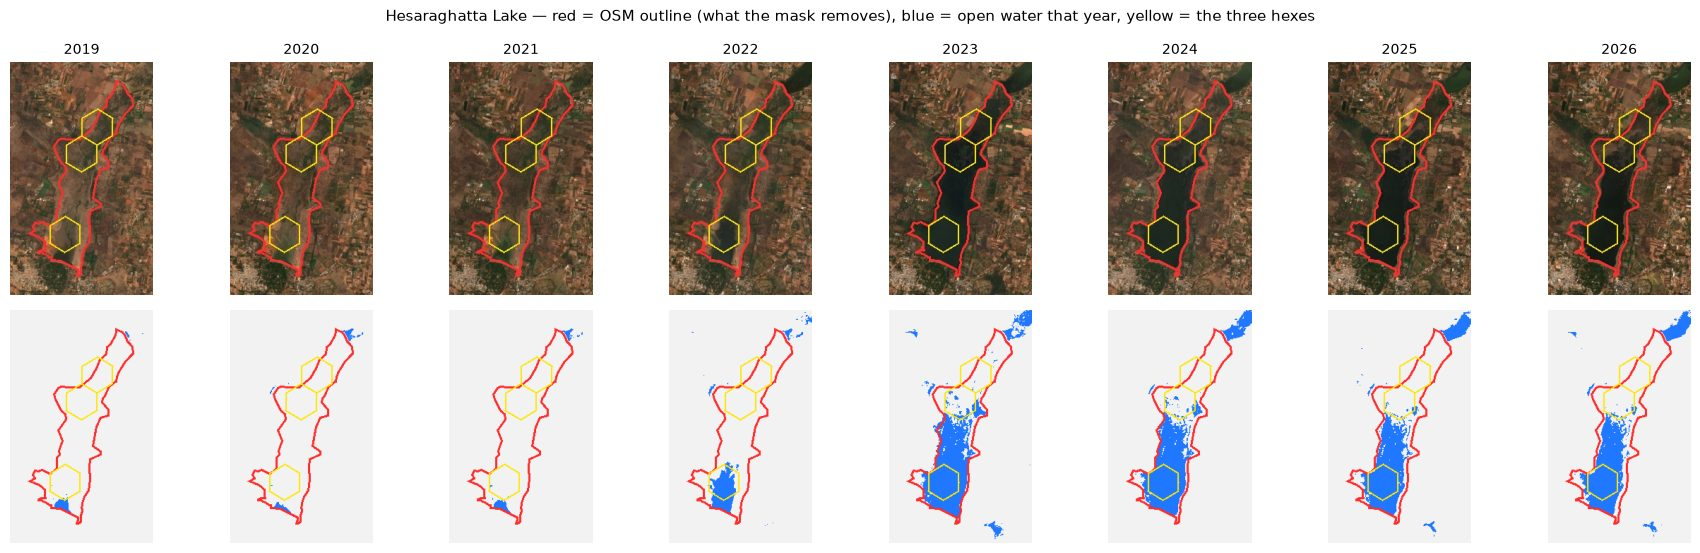

OSM outline: 5.98 km2
      water inside outline km2  water outside outline km2  share of outline that is water
year                                                                                     
2019                     0.140                      0.018                           0.023
2020                     0.064                      0.081                           0.011
2021                     0.116                      0.061                           0.019
2022                     0.774                      0.084                           0.129
2023                     3.098                      0.274                           0.518
2024                     2.801                      0.234                           0.468
2025                     2.502                      0.250                           0.418
2026                     2.410                      0.248                           0.403


In [4]:
lake = osm[osm.osm == "w41662659"]
lake_geom = ee.Geometry(lake.geometry.iloc[0].__geo_interface__)
region = lake_geom.buffer(600).bounds()
wide = lake_geom.buffer(600)
hexes = ["88601694a5fffff", "8860169481fffff", "88601694a1fffff"]
hex_fc = ee.FeatureCollection([ee.Feature(hex_geom(h)) for h in hexes])
lake_edge = outline(lake, MASK_EDGE, 3)
hex_edge = ee.Image().byte().paint(hex_fc, 1, 2).selfMask().visualize(palette=[HEX_EDGE])
lake_km2 = lake.to_crs(METRIC).area.iloc[0] / 1e6

rows = []
fig, axes = plt.subplots(2, len(YEARS), figsize=(18, 5.6))
for i, year in enumerate(YEARS):
    comp = composite(year, region)
    water = is_water(comp)
    inside = water.clip(lake_geom)
    outside = water.clip(wide.difference(lake_geom, 1))
    area = ee.Image.pixelArea().divide(1e6)
    stats = retry(ee.Dictionary({
        "inside": area.updateMask(inside).reduceRegion(ee.Reducer.sum(), lake_geom, 10).values().get(0),
        "outside": area.updateMask(outside).reduceRegion(ee.Reducer.sum(), wide, 10).values().get(0),
    }).getInfo)
    rows.append({"year": year, "water inside outline km2": stats["inside"],
                 "water outside outline km2": stats["outside"]})
    rgb = comp.visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX).blend(lake_edge).blend(hex_edge)
    wet = (ee.Image.constant(1).visualize(palette=["#f2f2f2"])
           .blend(water.selfMask().visualize(palette=[WATER_FILL]))
           .blend(lake_edge).blend(hex_edge))
    axes[0][i].imshow(thumb(rgb, region, "jpg", 330))
    axes[1][i].imshow(thumb(wet, region, "png", 330))
    axes[0][i].set_title(str(year), fontsize=10)
    for ax in axes[:, i]:
        ax.set_axis_off()
fig.suptitle("Hesaraghatta Lake — red = OSM outline (what the mask removes), blue = open water that year, "
             "yellow = the three hexes", fontsize=11)
plt.tight_layout(); plt.show()

hes = pd.DataFrame(rows).set_index("year")
hes["share of outline that is water"] = hes["water inside outline km2"] / lake_km2
print(f"OSM outline: {lake_km2:.2f} km2")
print(hes.round(3).to_string())

---
## What this shows

**Seven of the top 12 are real land being cleared or built on, and they are the clearest things in
the photos.**

| rank | where | what the photos show | verdict |
|---|---|---|---|
| 1 | Hennagara Lake (12.776, 77.659) | the hex is mostly lake, but OSM's outline covers only a sliver of it, so 9-42% of the "land" is water. The +0.31 "gain" is the lake surface changing (weed or turbidity) | **artefact**: lake that OSM doesn't map |
| 2 | east, near Whitefield (13.015, 77.747) | fields and mapped wetland patches scraped and built on from 2023 | **real loss**, including wetland |
| 3 | Ramapura Kere (13.046, 77.689) | a weed-covered lake bed and its wetland margin dug up from 2021, a lake works project | **real vegetation removal, but lake works**, not development |
| 4 | Hesaraghatta north (13.181, 77.497) | the land left is farm plots beside the reservoir; they are greener in 2026 | **doubtful**: crop swings (gotcha 3) |
| 5 | next to rank 2 (13.015, 77.739) | a green valley along a wetland channel, cleared for development from 2024 | **real loss**, including wetland |
| 6 | Shivaram Karanth Layout (13.106, 77.521) | farmland scraped and a road grid laid in 2024 | **real loss** |
| 7 | Hesaraghatta sliver (13.151, 77.488) | almost no land left; that land was underwater in 2023-24 | **artefact**: the sliver case |
| 8 | Ramapura, north side (13.053, 77.684) | buildings spreading across farmland year after year; lake works at the south edge | **real loss**, mostly |
| 9 | Shivaram Karanth Layout (13.091, 77.512) | same layout, cleared in 2024 | **real loss** |
| 10 | Shivaram Karanth Layout (13.098, 77.517) | same layout, road grid by 2025 | **real loss** |
| 11 | east, near rank 2 (13.015, 77.756) | a large construction site from 2023 | **real loss** |
| 12 | Bellandur (12.933, 77.666), 10% land | marsh dug up in 2024, open water in 2025 | **artefact**: lake works on a sliver of land |

Two clusters account for most of the real losses: the Shivaram Karanth Layout in Yelahanka (ranks 6, 9
and 10, plus hex B at rank 51) and a development area east of Whitefield (ranks 2, 5 and 11).

**The water check agrees with the photos.** Only 2 of the 12 had open water inside their "land" in any
year: rank 1, where the lake is bigger than its map, and rank 7, the sliver. The other ten are measured
on dry ground.

**Hesaraghatta: OSM's outline is good.** It is the full reservoir bed, 5.98 km². The reservoir was
almost dry in 2019-2021 (2% of the outline held water) and filled from 2022 (52% in 2023, 40% in
2026). Water outside the outline was small in every year: 0.02-0.27 km², mostly a separate stretch to
the north-east. So the mask removes the right ground there. The problem at Hesaraghatta was never the
outline; it was a dry lake bed reading as grassland and then flooding, and the mask now removes that.

**What's left, and what each would take:**

1. **Slivers (ranks 7, 12):** the 25% minimum-land cutoff removes exactly these two. The photos back
   applying it.
2. **Lakes OSM maps too small (rank 1):** one case in 12. Options are to flag it by eye, or to add
   pixels that read as water in several years to the mask. That second option is a wetness test
   again, which is why it isn't done here.
3. **Lake works (ranks 3, 12):** real vegetation removal, but a lake project rather than development.
   Keep it with a label, or leave it out of the headline list; that's an editorial call.
4. **Farmland crop swings (rank 4):** the known gotcha 3. Dynamic World land-cover classes are the fix
   the project already names.